In [41]:
import polars as pl

# remove subspecies reps that are uncertain
uhvdb_final_ids = set(
    pl.read_csv('../figure_1/uhvdb_hq_derep_hc_final_ids.txt', has_header=False, new_columns=['seq_header'])
        .with_columns([
            pl.col('seq_header').str.replace('^>', '').str.split(' ').list[0].alias('seq_name')
        ])['seq_name']
)

# assign genomes to full UHVDB taxa
genome2taxa = (
    # assign genomes to seqhash
    pl.read_csv('../uhvdb_creation/combined.seq-hasher.tsv', separator='\t', has_header=False, new_columns=['seq_name', 'seqhash'])
        .join(
            pl.read_csv('../uhvdb_creation/hq_viruses.csvtk_uniq.tsv.gz', separator='\t', has_header=False, new_columns=['seqhash_rep', 'seqhash']),
            on='seqhash', how='full', coalesce=True
        )
        .drop('seqhash')
        # assign seqhash to subspecies reps
        .join(
            pl.read_csv('../uhvdb_creation/uhvdb.vclust_derep_clusters.tsv', separator='\t').rename({'object':'seqhash_rep', 'cluster':'subspecies_rep'}),
            on='seqhash_rep', how='full', coalesce=True
        )
        # remove subspecies reps that are uncertain
        .filter(pl.col('subspecies_rep').is_in(uhvdb_final_ids))
        # assign subspecies reps to species reps
        .join(
            pl.read_csv('../uhvdb_clustering/vclust/uhvdb_vclust_cluster_info_final.tsv', separator='\t', columns=['contig_id', 'votu_rep']).rename({'contig_id':'subspecies_rep'}),
            on='subspecies_rep', how='full', coalesce=True
        )
        # assign species reps to subgenera
        .join(
            pl.read_csv('../uhvdb_clustering/protein_similarity/uhvdb_subgenus_clusters.tsv', separator='\t').rename({'contig_id':'votu_rep', 'cluster_id':'subgenus_cluster'}),
            on='votu_rep', how='full', coalesce=True
        )
        # assign species reps to genus
        .join(
            pl.read_csv('../uhvdb_clustering/protein_similarity/uhvdb_genus_clusters.tsv', separator='\t').rename({'contig_id':'votu_rep', 'cluster_id':'genus_cluster'}),
            on='votu_rep', how='full', coalesce=True
        )
        # assign species reps to subfamily
        .join(
            pl.read_csv('../uhvdb_clustering/protein_similarity/uhvdb_subfamily_clusters.tsv', separator='\t').rename({'contig_id':'votu_rep', 'cluster_id':'subfamily_cluster'}),
            on='votu_rep', how='full', coalesce=True
        )
        # assign species reps to family
        .join(
            pl.read_csv('../uhvdb_clustering/protein_similarity/uhvdb_family_clusters.tsv', separator='\t').rename({'contig_id':'votu_rep', 'cluster_id':'family_cluster'}),
            on='votu_rep', how='full', coalesce=True
        )
)

genome2taxa.write_csv('genome2taxa.csv', include_header=True)

In [ ]:
seqhash_count = (
    genome2taxa
        .group_by('seqhash_rep')
        .agg([
            pl.col('seq_name').len().alias('genomes_in_seqhash')
        ])
)

subspecies_count = (
    genome2taxa
        .group_by(['seqhash_rep', 'subspecies_rep'])
        .agg([
            pl.col('seq_name').len().alias('genomes_in_seqhash')
        ])
        .group_by('subspecies_rep')
        .agg([
            pl.sum('genomes_in_seqhash').alias('genomes_in_subspecies'),
            pl.col('seqhash_rep').len().alias('seqhashes_in_subspecies')
        ])
)

votu_count = (
    genome2taxa
        .group_by(['seqhash_rep', 'subspecies_rep', 'votu_rep'])
        .agg([
            pl.col('seq_name').len().alias('genomes_in_seqhash')
        ])
        .group_by(['subspecies_rep', 'votu_rep'])
        .agg([
            pl.col('genomes_in_seqhash').sum().alias('genomes_in_subspecies'),
            pl.col('seqhash_rep').len().alias('seqhashes_in_subspecies')
        ])
        .group_by('votu_rep')
        .agg([
            pl.col('genomes_in_subspecies').sum().alias('genomes_in_votu'),
            pl.col('seqhashes_in_subspecies').sum().alias('seqhashes_in_votu'),
            pl.col('subspecies_rep').len().alias('subspecies_in_votu')
        ])
)

subgenus_count = (
    genome2taxa
        .group_by(['seqhash_rep', 'subspecies_rep', 'votu_rep', 'subgenus_cluster'])
        .agg([
            pl.col('seq_name').len().alias('genomes_in_seqhash')
        ])
        .group_by(['subspecies_rep', 'votu_rep', 'subgenus_cluster'])
        .agg([
            pl.col('genomes_in_seqhash').sum().alias('genomes_in_subspecies'),
            pl.col('seqhash_rep').len().alias('seqhashes_in_subspecies')
        ])
        .group_by(['votu_rep', 'subgenus_cluster'])
        .agg([
            pl.col('genomes_in_subspecies').sum().alias('genomes_in_votu'),
            pl.col('seqhashes_in_subspecies').sum().alias('seqhashes_in_votu'),
            pl.col('subspecies_rep').len().alias('subspecies_in_votu')
        ])
        .group_by(['subgenus_cluster'])
        .agg([
            pl.col('genomes_in_votu').sum().alias('genomes_in_subgenus'),
            pl.col('seqhashes_in_votu').sum().alias('seqhashes_in_subgenus'),
            pl.col('subspecies_in_votu').sum().alias('subspecies_in_subgenus'),
            pl.col('votu_rep').len().alias('votus_in_subgenus')
        ])
)

genome2taxa_w_counts = (
    genome2taxa
        .join(seqhash_count, on='seqhash_rep', how='left')
        .join(subspecies_count, on='subspecies_rep', how='left')
        .join(votu_count, on='votu_rep', how='left')
        .join(subgenus_count, on='subgenus_cluster', how='left')
        [[
            'seq_name', 
            'seqhash_rep', 'genomes_in_seqhash', 
            'subspecies_rep', 'genomes_in_subspecies', 'seqhashes_in_subspecies',
            'votu_rep', 'genomes_in_votu', 'seqhashes_in_votu', 'subspecies_in_votu',
            'subgenus_cluster', 'genomes_in_subgenus', 'seqhashes_in_subgenus', 'subspecies_in_subgenus', 'votus_in_subgenus',
        ]]
)

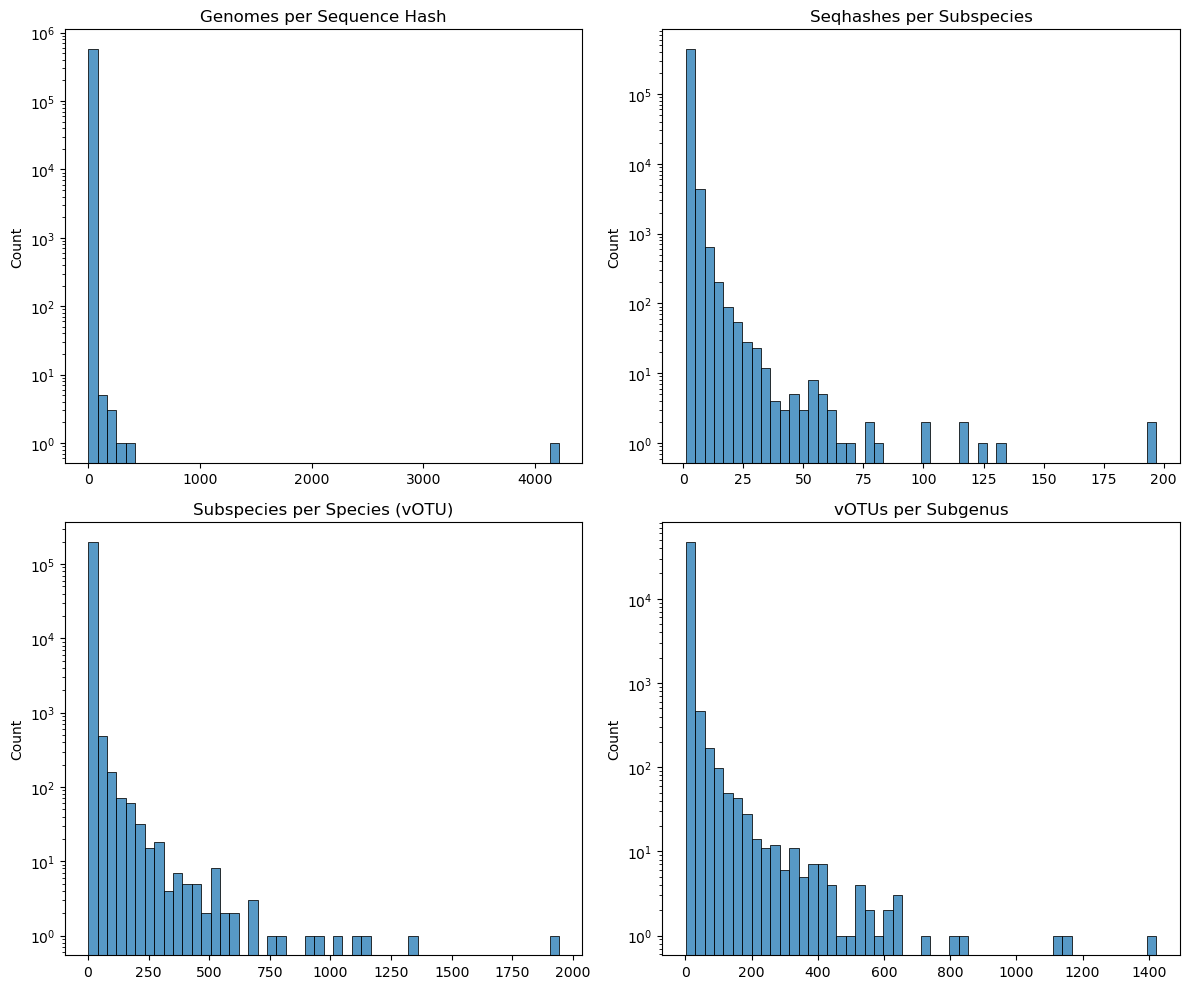

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# visualize distributions of cluster sizes at each taxonomic level
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(genome2taxa_w_counts.unique('seqhash_rep')['genomes_in_seqhash'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Genomes per Sequence Hash')
axes[0,0].set_yscale('log')

sns.histplot(genome2taxa_w_counts.unique('subspecies_rep')['seqhashes_in_subspecies'], bins=50, ax=axes[0,1])
axes[0,1].set_title('Seqhashes per Subspecies')
axes[0,1].set_yscale('log')

sns.histplot(genome2taxa_w_counts.unique('votu_rep')['subspecies_in_votu'], bins=50, ax=axes[1,0])
axes[1,0].set_title('Subspecies per Species (vOTU)')
axes[1,0].set_yscale('log')

sns.histplot(genome2taxa_w_counts.unique('subgenus_cluster')['votus_in_subgenus'], bins=50, ax=axes[1,1])
axes[1,1].set_title('vOTUs per Subgenus')
axes[1,1].set_yscale('log')


plt.tight_layout()

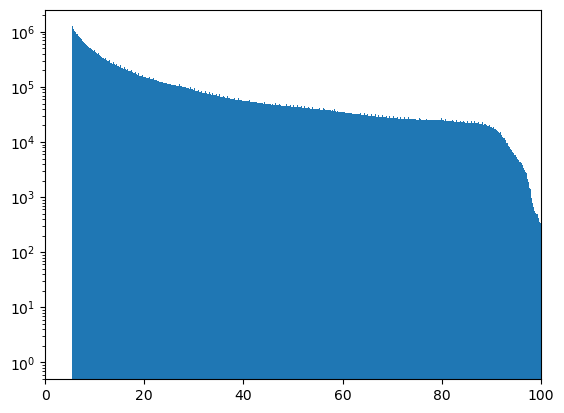

In [90]:
# plot distrubtion of norm scores

family_normscores = pl.read_csv('../uhvdb_clustering/protein_similarity/uhvdb_family_normscores.tsv', separator='\t', has_header=False)

plt.hist(family_normscores['column_3'], bins=1000)
plt.xlim(0, 100)
plt.yscale('log')
plt.show()

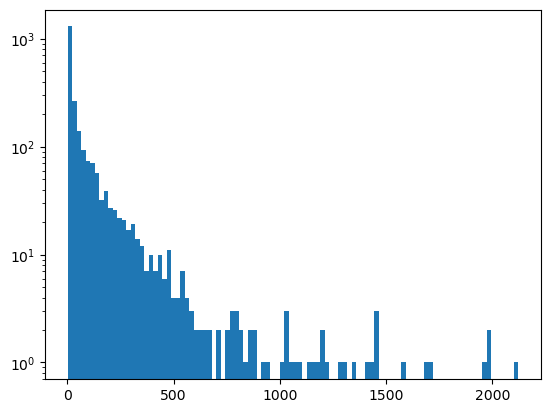

In [30]:
import matplotlib.pyplot as plt

votus_per_family = (
    genome2taxa
        .group_by(['votu_rep', 'family_cluster'])
        .len()
        .group_by(['family_cluster'])
        .agg([
            pl.col('votu_rep').len().alias('votus_in_family')
        ])
)

plt.hist(votus_per_family['votus_in_family'], bins=100)
plt.yscale('log')
plt.show()

In [37]:
votus_per_family.filter(pl.col('votus_in_family') > 500)['votus_in_family'].sum()

69456

In [38]:
votus_per_family.filter(pl.col('votus_in_family') > 500).unique('family_cluster')

family_cluster,votus_in_family
i64,u32
10,1455
46,707
65,541
29,945
11,1436
…,…
14,1306
22,1095
68,535
